In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from probcs.models.pattern_completion_model import PatternCompletionModel, BinaryPatternCompletionModel
from probcs.experiment_running.exc_experiment import center_surround_experiment, create_stimuli
from probcs.utils.utils import load_images
from torchvision import transforms
import arviz as az
from sklearn.metrics.pairwise import cosine_similarity
from probcs.utils.utils import select_focus_images, get_excitatory_images
from probcs.utils.plotting import plot_posterior_binary
seed = 42
rng = np.random.default_rng(seed)

In [2]:
natimgs = load_images(
    crop_size=36,
    n_samples=1000,
    transform=transforms.Compose([
        transforms.Resize(36),
    ])
)
natimgs = natimgs - natimgs.mean(axis=0)

In [3]:
I_empirical_std = natimgs.std(axis=0).mean()

In [4]:
natimgs.min(), natimgs.max(), natimgs.mean(), natimgs.std()

(-121.9, 152.16, -3.0316490059097607e-16, 58.44170205445427)

In [89]:
G_dim = 5
G_prob = 0.5
I_sigma = 150
patterns_offset = 0

G_visual_nrows = G_dim
G_visual_ncols = 1
x_visual_nrows = G_dim
x_visual_ncols = 9
n_tune = 500
n_draws = 500
n_chains = 4
n_cores = 4

In [90]:
patterns, cossim = select_focus_images(
    image_dataset=natimgs,
    threshold_low=-0.5,
    threshold_high=0.5,
    num_focus_images=G_dim,
    seed=33
)
patterns = np.array(patterns)
vmin = patterns.min()
vmax = patterns.max()
# patterns = natimgs[:G_dim]

In [91]:
vmin, vmax

(-116.971, 138.8)

In [92]:
mapping = np.zeros((G_dim*9, G_dim)) + 0.05
for j in range(0, G_dim*9, G_dim):
    for i in range(G_dim):
        mapping[i + j, i] = 0.8

In [93]:
model = BinaryPatternCompletionModel(
    patterns=patterns,
    G_prob=G_prob,
    I_sigma=I_sigma,
    patterns_offset=patterns_offset,
    g_x_mapping=mapping
)

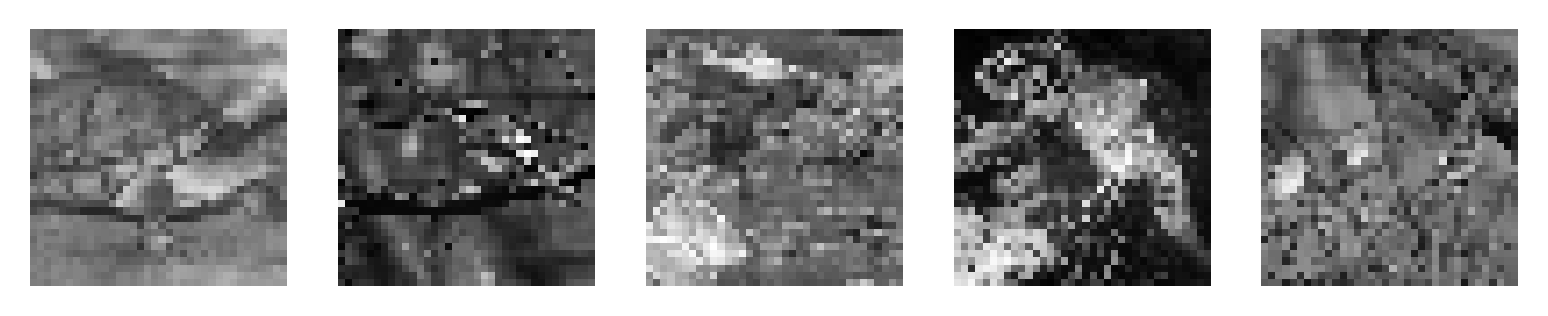

In [94]:
fig, axs = plt.subplots(1, G_dim, dpi=300)
for ax, pattern in zip(axs.flatten(), patterns):
    ax.imshow(pattern, cmap="gray", vmin=vmin, vmax=vmax)
    ax.axis("off")

In [95]:
cossim = cosine_similarity(model.patterns.reshape(model.patterns.shape[0], -1))

Text(0.5, 1.0, 'Cos sim between assigned Gs')

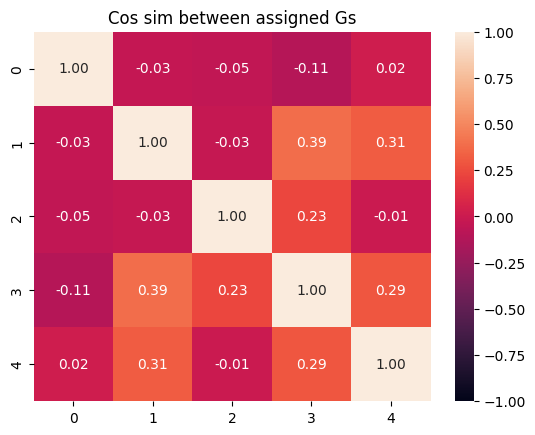

In [96]:
fig, ax = plt.subplots(dpi=100)
sns.heatmap(cossim, vmin=-1, vmax=1, annot=True, fmt=".2f", ax=ax)
ax.set_title("Cos sim between assigned Gs")

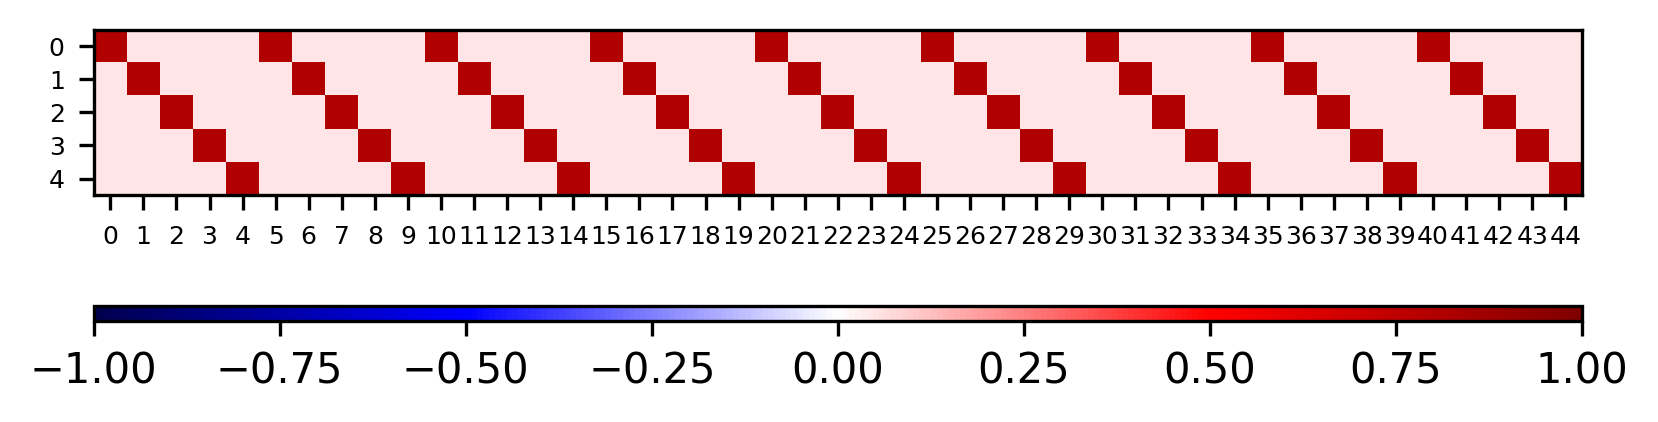

In [97]:
fig, ax = plt.subplots(dpi=300)
ax.imshow(model.G_X_mapping.T, cmap="seismic", vmin=-1, vmax=1)
ax.set_xticks(np.arange(G_dim*9))
ax.set_xticklabels(np.arange(G_dim*9))
ax.set_yticks(np.arange(G_dim))
ax.set_yticklabels(np.arange(G_dim))
ax.tick_params(axis='both', which='major', labelsize=6)
# draw a small horizontal colorbar
cbar = fig.colorbar(ax.get_images()[0], ax=ax, orientation="horizontal", pad=0.1, aspect=100)

In [98]:
MEIs, completing_patterns, disrupting_patterns_1, disrupting_patterns_2, disrupting_pattern_indices = create_stimuli(patterns)

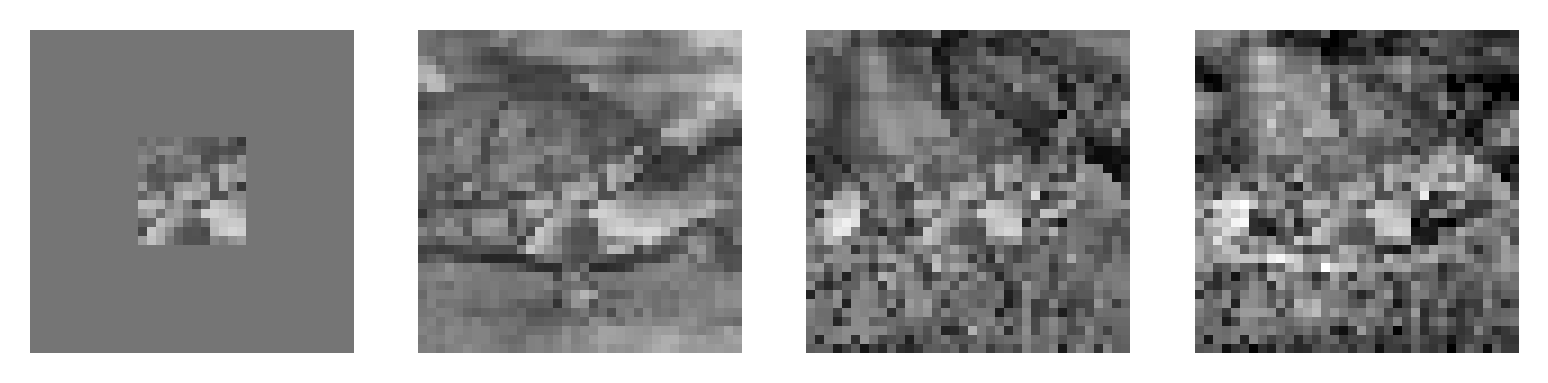

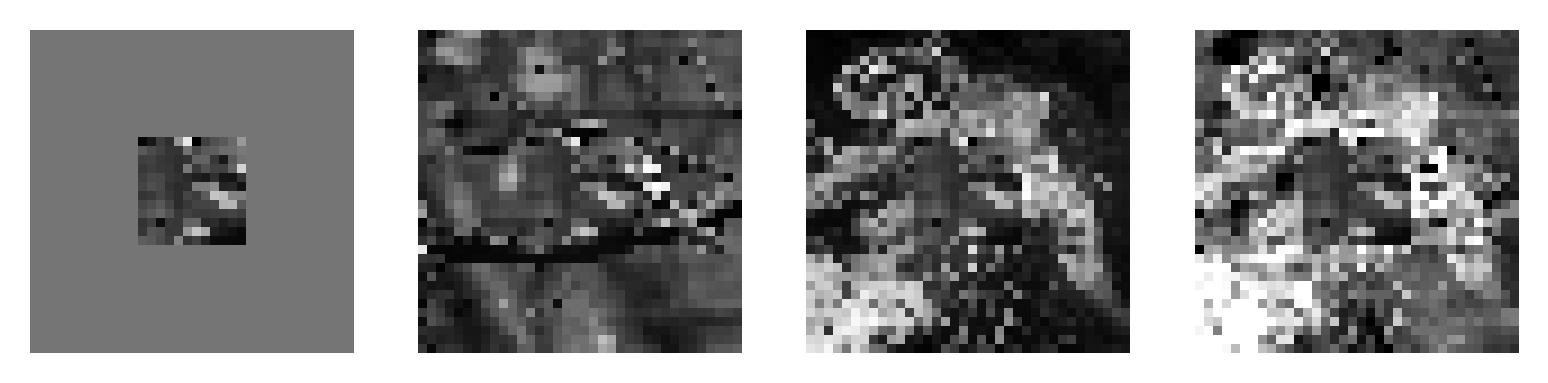

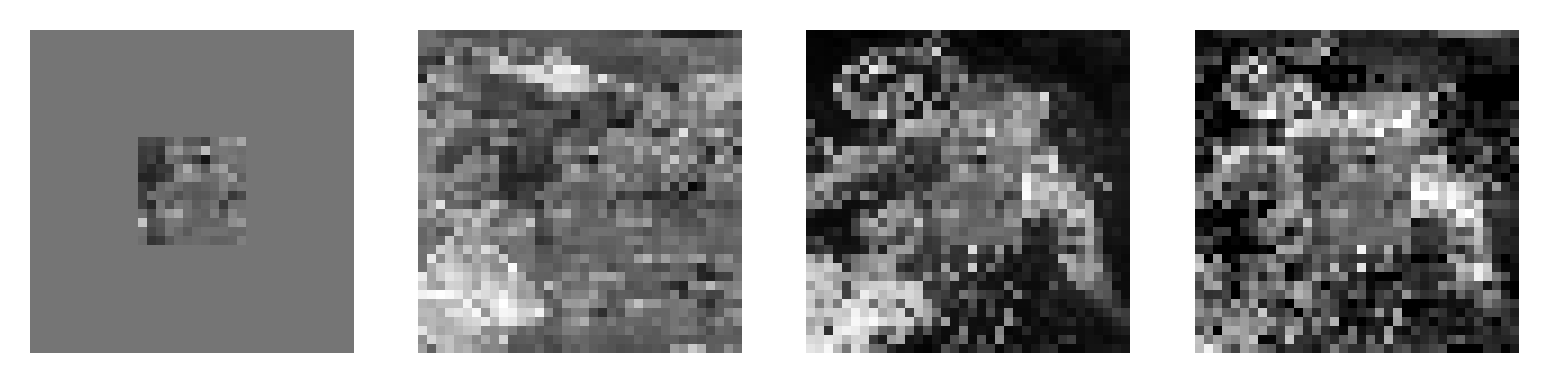

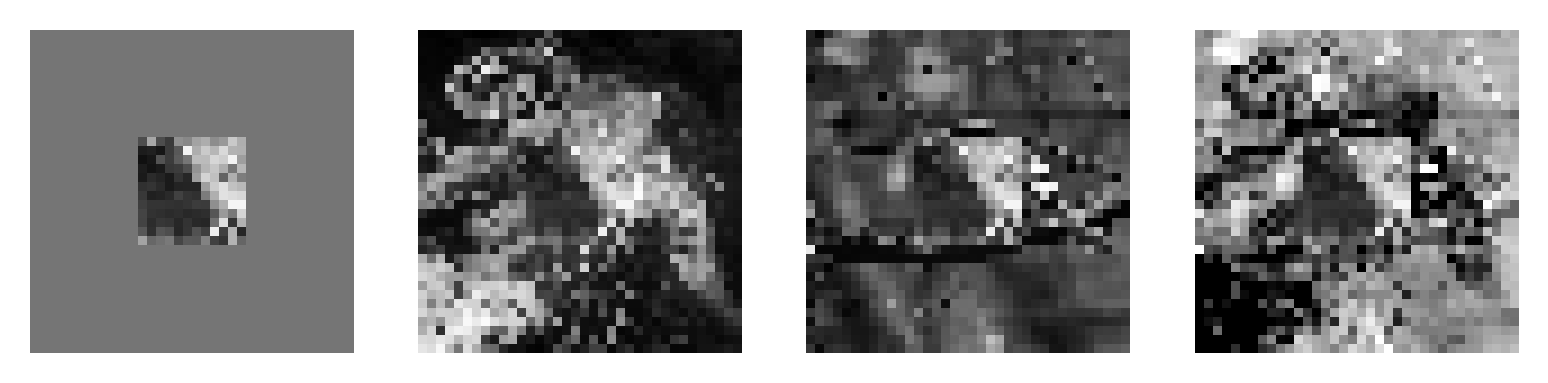

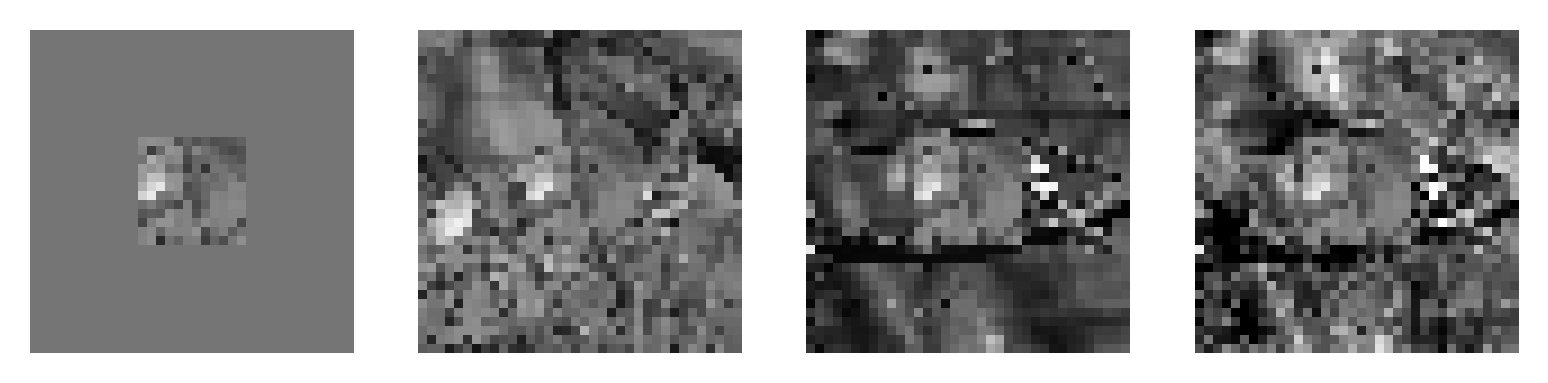

In [99]:
for MEI, completing_pattern, disrupting_pattern_1, disrupting_pattern_2 in zip(MEIs, completing_patterns, disrupting_patterns_1, disrupting_patterns_2):
    fig, axs = plt.subplots(1, 4, dpi=300)
    axs[0].imshow(MEI, cmap="gray", vmin=vmin, vmax=vmax)
    axs[0].axis("off")
    axs[1].imshow(completing_pattern, cmap="gray", vmin=vmin, vmax=vmax)
    axs[1].axis("off")
    axs[2].imshow(disrupting_pattern_1, cmap="gray", vmin=vmin, vmax=vmax)
    axs[2].axis("off")
    axs[3].imshow(disrupting_pattern_2, cmap="gray", vmin=vmin, vmax=vmax)
    axs[3].axis("off")

In [100]:
all_idata = []
for MEI, completing_pattern, disrupting_pattern_1, disrupting_pattern_2 in zip(MEIs, completing_patterns, disrupting_patterns_1, disrupting_patterns_2):
    idata_set = []
    idata = model(
        image=MEI,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed
    )
    idata_set.append(idata)
    # break
    idata = model(
        image=completing_pattern,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed
    )
    idata_set.append(idata)
    idata = model(
        image=disrupting_pattern_1,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed
    )
    idata_set.append(idata)
    idata = model(
        image=disrupting_pattern_2,
        n_samples=n_draws,
        tune=n_tune,
        chains=n_chains,
        cores=n_cores,
        random_seed=seed
    )
    idata_set.append(idata)
    all_idata.append(idata_set)
    break

Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 62 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 65 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 67 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Multiprocess sampling (4 chains in 4 jobs)
BinaryGibbsMetropolis: [G, X]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 69 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


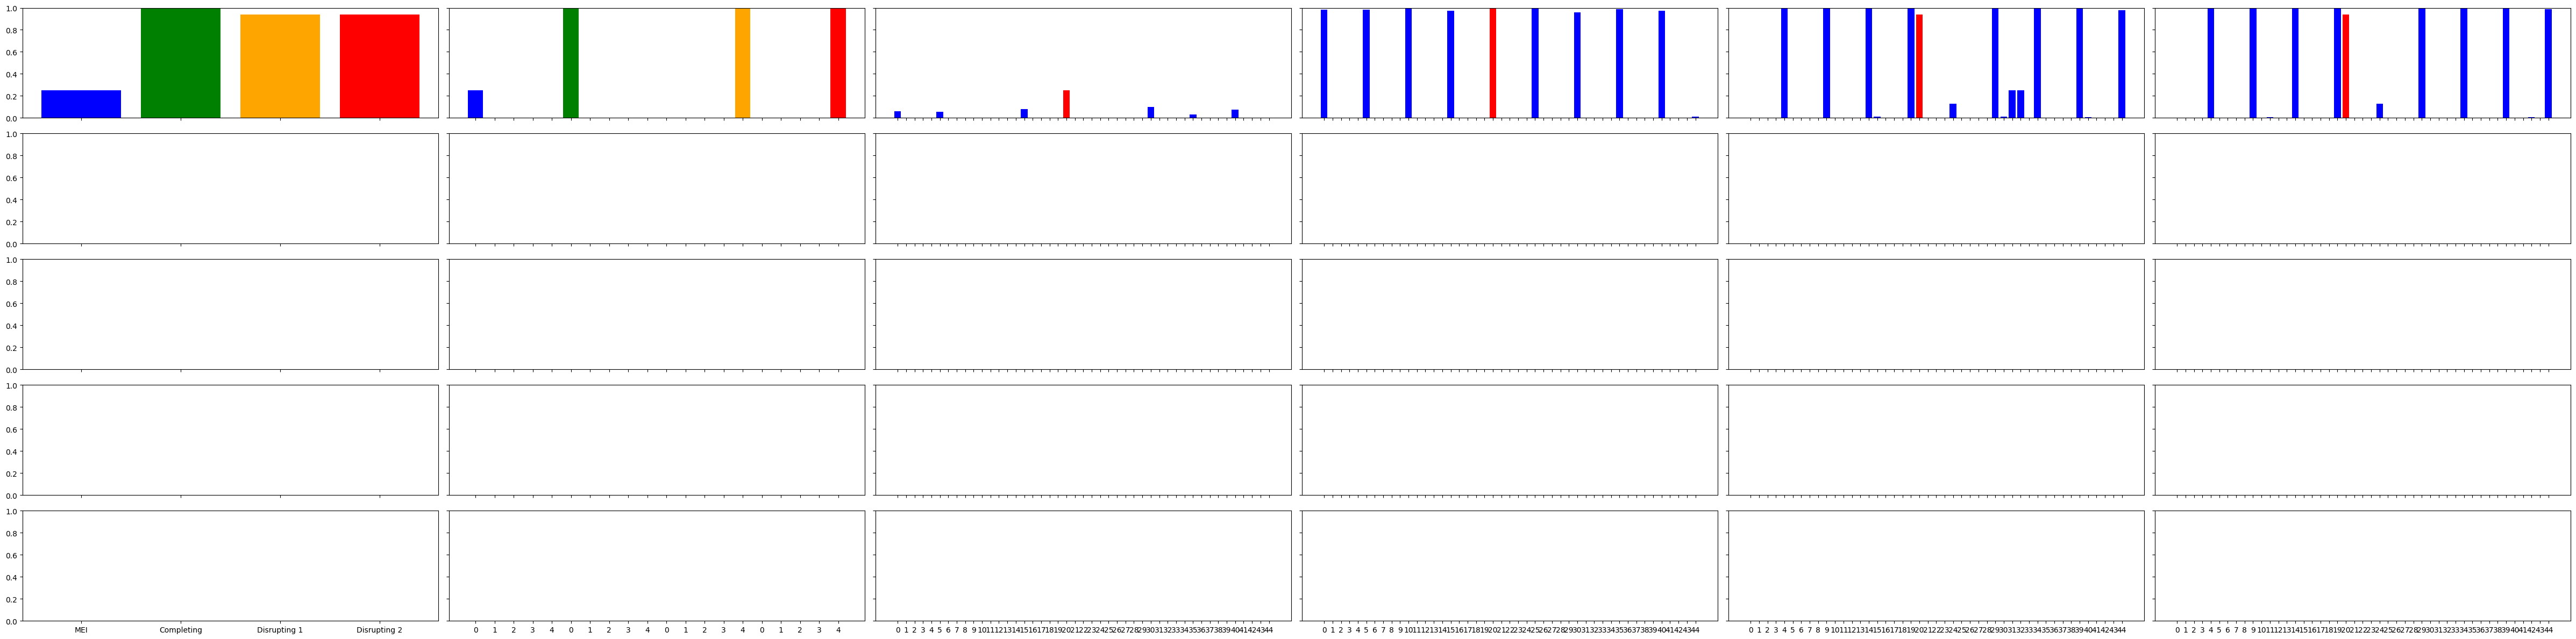

In [101]:
fig, axs, completing_perc_diff_list, disrupting_1_perc_diff_list, disrupting_2_perc_diff_list = plot_posterior_binary(G_dim, disrupting_pattern_indices, all_idata)